# EDA: FIPS payments (scratch)

Throwaway exploration of the raw `Practice_FIPS_23-25.csv`. This notebook is **gitignored** — flail freely. Once a cleaning decision is settled, move the logic into `src/nrcs_navigator/data/fips_payments.py` and keep only the narrative in `notebooks/01_data_pipeline.ipynb`.

In [2]:
import pandas as pd

from nrcs_navigator.data import fips_payments

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

df = fips_payments.load_raw()
print(df.shape)
df.head()

(32744, 9)


,STATE,COUNTY/CD,PROGRAM,PRACTICE NAME,FISCAL YEAR,PRACTICE INSTANCE COUNT,DOLLARS OBLIGATED,INDEX(),State
0,Alabama,Total,CSP-GCI,Grassland Conservation Initiative (E300GCI),2023,95,"$52,961",1,
1,Alabama,Total,CSP-GCI,Grassland Conservation Initiative (E300GCI),2024,70,"$66,915",2,
2,Alabama,Total,CSP-GCI,Total,2023,95,"$52,961",3,
3,Alabama,Total,CSP-GCI,Total,2024,70,"$66,915",4,
4,Alabama,Total,CStwP Farm Bill,Adding food-producing trees and shrubs to exis...,2023,NaN,NaN,5,(supp)


## Shape, columns, dtypes
Everything reads as `object` despite some columns being numeric. Note the two `State`-ish columns.

In [3]:
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32744 entries, 0 to 32743
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   STATE                    32744 non-null  object
 1   COUNTY/CD                32744 non-null  object
 2   PROGRAM                  32744 non-null  object
 3   PRACTICE NAME            32744 non-null  object
 4   FISCAL YEAR              32744 non-null  int64 
 5   PRACTICE INSTANCE COUNT  20202 non-null  object
 6   DOLLARS OBLIGATED        20202 non-null  object
 7   INDEX()                  32744 non-null  object
 8   State                    32744 non-null  object
dtypes: int64(1), object(8)
memory usage: 2.2+ MB


STATE                      object
COUNTY/CD                  object
PROGRAM                    object
PRACTICE NAME              object
FISCAL YEAR                 int64
PRACTICE INSTANCE COUNT    object
DOLLARS OBLIGATED          object
INDEX()                    object
State                      object
dtype: object

## Issue 1 — DOLLARS OBLIGATED is a string ($52,961)
Needs `$` and `,` stripped, then cast to a number.

In [4]:
df["DOLLARS OBLIGATED"].head(10)

0    $52,961
1    $66,915
2    $52,961
3    $66,915
4        NaN
5        NaN
6        NaN
7    $12,160
8    $11,584
9        NaN
Name: DOLLARS OBLIGATED, dtype: object

## Issue 2 — `Total` roll-up rows
`COUNTY/CD` and `PRACTICE NAME` both contain `Total` aggregate rows. Decide whether to drop them so we don't double-count.

In [5]:
print(df["COUNTY/CD"].value_counts().head())
print()
print((df["PRACTICE NAME"] == "Total").sum(), "rows where PRACTICE NAME == 'Total'")

COUNTY/CD
Total    32744
Name: count, dtype: int64

757 rows where PRACTICE NAME == 'Total'


## Issue 3 — practice code embedded in PRACTICE NAME
e.g. `Grassland Conservation Initiative (E300GCI)` — the code lives in parens and needs extracting into its own column.

In [6]:
df["PRACTICE NAME"].str.extract(r"\(([^)]+)\)$").value_counts().head(20)

0  
340    530
612    485
512    460
314    459
315    457
528    449
590    448
327    447
484    447
666    438
490    414
420    390
382    384
328    380
342    346
645    346
649    345
329    341
614    340
516    331
Name: count, dtype: int64

## Issue 4 — PROGRAM values (scope filter)
Confirm which programs are present vs the in-scope set (EQIP Farm Bill, EQIP IRA, CStwP Farm Bill, CStwP IRA, CSP-GCI, RCPP-CSP, RCPP-EQIP).

In [7]:
df["PROGRAM"].value_counts()

PROGRAM
CStwP Farm Bill    11542
EQIP Farm Bill     10806
CStwP IRA           5518
EQIP IRA            4039
AMA                  441
RCPP-EQIP            224
CSP-GCI              141
RCPP-CSP              33
Name: count, dtype: int64

## Issue 5 — the trailing empty `State` column and INDEX()
Both look droppable. Confirm before removing.

In [8]:
print(df["State"].value_counts(dropna=False).head())
df["INDEX()"].head()

State
          20202
(supp)    12542
Name: count, dtype: int64


0    1
1    2
2    3
3    4
4    5
Name: INDEX(), dtype: object

## Visualizations

Four views that characterize the data and justify the cleaning decisions in `fips_payments.clean()`. These run on the cleaned frame (and the raw frame for the disposition chart); plotting stays in the notebook, not in `src`.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

raw = fips_payments.load_raw()
clean = fips_payments.load_clean()

### 1. Row disposition
Defends every drop: replays the same order `clean()` uses so the buckets are disjoint and sum to the kept rows.

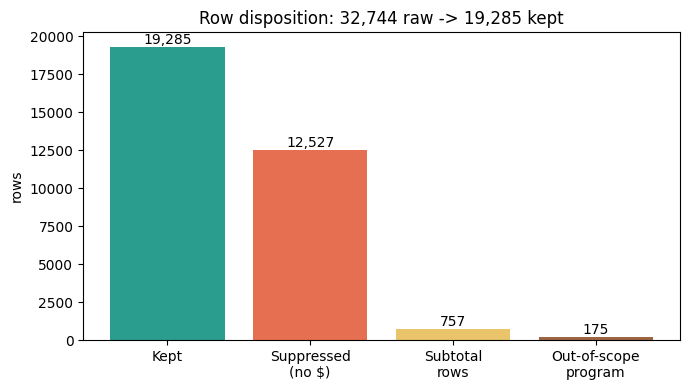

In [10]:
n_raw = len(raw)
s1 = raw[raw['PRACTICE NAME'] != 'Total']
n_subtotal = n_raw - len(s1)
s2 = s1[s1['DOLLARS OBLIGATED'].notna()]
n_suppressed = len(s1) - len(s2)
s3 = s2[s2['PROGRAM'].isin(fips_payments.IN_SCOPE_PROGRAMS)]
n_out_of_scope = len(s2) - len(s3)
n_kept = len(s3)

labels = ['Kept', 'Suppressed\n(no $)', 'Subtotal\nrows', 'Out-of-scope\nprogram']
counts = [n_kept, n_suppressed, n_subtotal, n_out_of_scope]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, counts, color=['#2a9d8f', '#e76f51', '#e9c46a', '#9c6644'])
ax.bar_label(bars, fmt='{:,.0f}')
ax.set_ylabel('rows')
ax.set_title(f'Row disposition: {n_raw:,} raw -> {n_kept:,} kept')
plt.tight_layout(); plt.show()

### 2. Payment per instance is right-skewed
Log x-axis spans $0.80 to ~$1.1M. The long right tail is why the `payment_estimator` should report a range, not a point estimate.

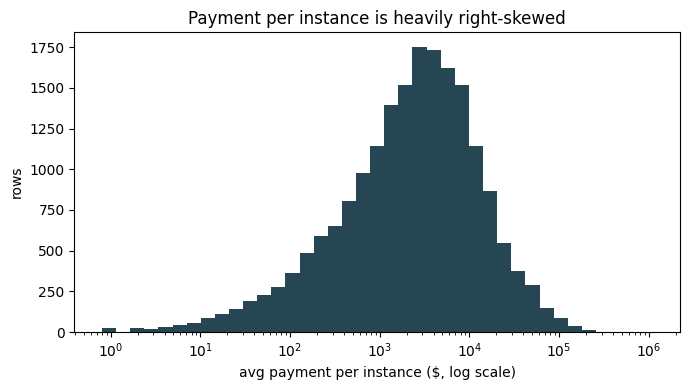

In [11]:
vals = clean['avg_payment_per_instance']
bins = np.logspace(np.log10(vals.min()), np.log10(vals.max()), 40)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(vals, bins=bins, color='#264653')
ax.set_xscale('log')
ax.set_xlabel('avg payment per instance ($, log scale)')
ax.set_ylabel('rows')
ax.set_title('Payment per instance is heavily right-skewed')
plt.tight_layout(); plt.show()

### 3. Rows by program
Scope composition: EQIP and CStwP (CSP) dominate; RCPP and CSP-GCI are thin.

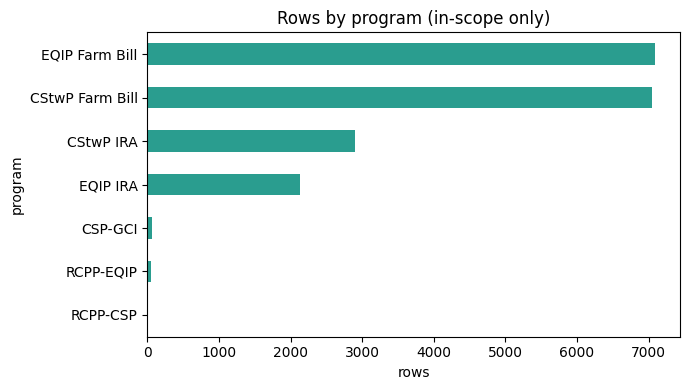

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
clean['program'].value_counts().sort_values().plot.barh(ax=ax, color='#2a9d8f')
ax.set_xlabel('rows')
ax.set_title('Rows by program (in-scope only)')
plt.tight_layout(); plt.show()

### 4. Rows by fiscal year
Confirms FY2023 to FY2025 coverage.

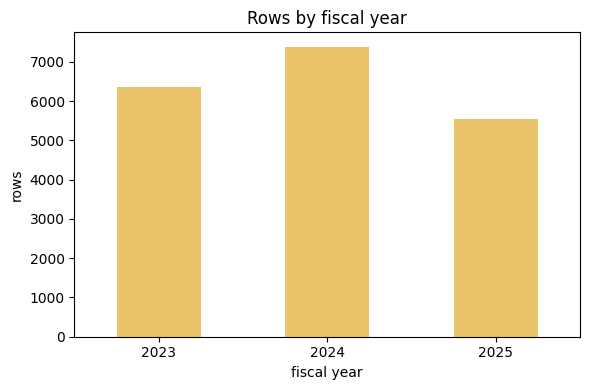

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
clean['fiscal_year'].value_counts().sort_index().plot.bar(ax=ax, color='#e9c46a', rot=0)
ax.set_xlabel('fiscal year')
ax.set_ylabel('rows')
ax.set_title('Rows by fiscal year')
plt.tight_layout(); plt.show()